In [2]:
# ==============================
# 1️⃣ Install Libraries (Kaggle usually has torch)
# ==============================
!pip install timm -q

In [3]:

# ==============================
# 2️⃣ Imports
# ==============================
import os
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
from tqdm import tqdm

In [4]:
# ==============================
# 3️⃣ Configuration
# ==============================
path = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset"  # change path
BATCH_SIZE = 32
EPOCHS = 15
LR = 0.0001
IMG_SIZE = 224

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
import os
from torchvision import datasets
from torch.utils.data import DataLoader

# The path based on your specific 'color' subdirectory find
data_root = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"

# Verify the contents—you should see folder names like 'Apple___Apple_scab', etc.
print("Actual classes found:", os.listdir(data_root))

# Load the dataset
# Note: If this folder contains the classes directly (no 'train'/'val' split), 
# you'll need to manually split the dataset.
full_dataset = datasets.ImageFolder(root=data_root, transform=train_transforms)

# Example: 80/20 Split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total images: {len(full_dataset)}")

Actual classes found: ['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Strawberry___Leaf_scorch', 'Peach___healthy', 'Apple___Apple_scab', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Apple___Black_rot', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Peach___Bacterial_spot', 'Apple___Cedar_apple_rust', 'Tomato___Target_Spot', 'Pepper,_bell___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Potato___Late_blight', 'Tomato___Tomato_mosaic_virus', 'Strawberry___healthy', 'Apple___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Common_rust_', 'Grape___Esca_(Black_Measles)', 'Raspberry___healthy', 'Tomato__

NameError: name 'train_transforms' is not defined

In [6]:
# ==============================
# 4️⃣ Data Transforms
# ==============================
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [7]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    break

/kaggle/input


In [8]:
!ls /kaggle/input

datasets


In [10]:
!ls /kaggle/input/datasets/abdallahalidev/plantvillage-dataset

 color	 grayscale  'plantvillage dataset'   segmented


In [11]:
from torch.utils.data import random_split

DATA_DIR = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"

full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transforms)

# 80-20 split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply validation transform separately
val_dataset.dataset.transform = val_transforms

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

num_classes = len(full_dataset.classes)
print("Classes:", full_dataset.classes)

Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___

In [12]:
# ==============================
# 6️⃣ Load EfficientNet-B0
# ==============================
model = timm.create_model("efficientnet_b0", pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, num_classes)
model = model.to(device)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [13]:
# ==============================
# 7️⃣ Loss & Optimizer
# ==============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [14]:
# ==============================
# 8️⃣ Training Function
# ==============================
def train_one_epoch():
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    accuracy = 100. * correct / total
    return running_loss/len(train_loader), accuracy

In [15]:
# ==============================
# 9️⃣ Validation Function
# ==============================
def validate():
    model.eval()
    running_loss = 0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = 100. * correct / total
    return running_loss/len(val_loader), accuracy, all_preds, all_labels

In [16]:
# ==============================
# 🔟 Training Loop + Early Stopping
# ==============================
best_acc = 0
patience = 3
trigger = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    train_loss, train_acc = train_one_epoch()
    val_loss, val_acc, preds, labels = validate()
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "efficientnet_plant_best.pth")
        print("✅ Model Saved!")
        trigger = 0
    else:
        trigger += 1
        if trigger >= patience:
            print("⛔ Early Stopping Triggered")
            break


Epoch 1/15


100%|██████████| 1358/1358 [06:58<00:00,  3.25it/s]


Train Loss: 0.3225 | Train Acc: 93.18%
Val Loss: 0.0227 | Val Acc: 99.52%
✅ Model Saved!

Epoch 2/15


100%|██████████| 1358/1358 [04:26<00:00,  5.10it/s]


Train Loss: 0.0261 | Train Acc: 99.30%
Val Loss: 0.0174 | Val Acc: 99.52%

Epoch 3/15


...

Train Loss: 0.0071 | Train Acc: 99.79%
Val Loss: 0.0140 | Val Acc: 99.67%

Epoch 8/15


100%|██████████| 1358/1358 [04:30<00:00,  5.02it/s]


Train Loss: 0.0065 | Train Acc: 99.80%
Val Loss: 0.0192 | Val Acc: 99.54%

Epoch 9/15


100%|██████████| 1358/1358 [04:26<00:00,  5.10it/s]


Train Loss: 0.0045 | Train Acc: 99.86%
Val Loss: 0.0166 | Val Acc: 99.64%
⛔ Early Stopping Triggered


In [18]:
# ==============================
# 1️⃣1️⃣ Final Evaluation
# ==============================
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=full_dataset.classes))
print("Training Complete 🚀")


Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.99      1.00       126
                                 Apple___Black_rot       1.00      1.00      1.00       107
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        57
                                   Apple___healthy       1.00      0.99      1.00       352
                               Blueberry___healthy       1.00      0.99      1.00       307
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       197
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       168
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.99      0.89      0.94        94
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       238
               Corn_(maize)___Northern_Leaf_Blight     

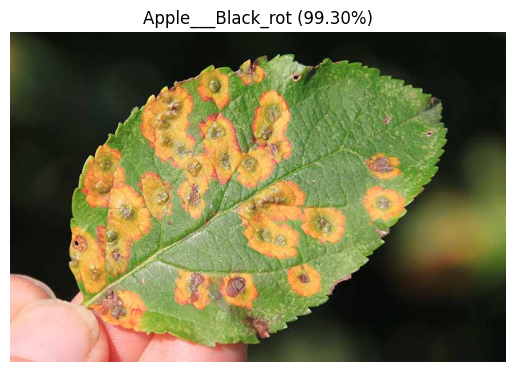

Prediction: Apple___Black_rot
Confidence: 99.30%


In [22]:
import torch
import timm
from torchvision import transforms
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Use classes directly from dataset
class_names = full_dataset.classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model = timm.create_model("efficientnet_b0", pretrained=False)
model.classifier = nn.Linear(model.classifier.in_features, len(class_names))
model.load_state_dict(torch.load("efficientnet_plant_best.pth", map_location=device))
model.to(device)
model.eval()

# CHANGE THIS PATH
image_path = "/kaggle/input/datasets/arunsworkspace/test-sample/Cedar-Apple-Rust-on-Foliage.jpg"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(input_tensor)
    probs = F.softmax(outputs, dim=1)
    confidence, predicted = torch.max(probs, 1)

predicted_class = class_names[predicted.item()]
confidence_score = confidence.item() * 100

plt.imshow(image)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence_score:.2f}%)")
plt.show()

print("Prediction:", predicted_class)
print("Confidence:", f"{confidence_score:.2f}%")

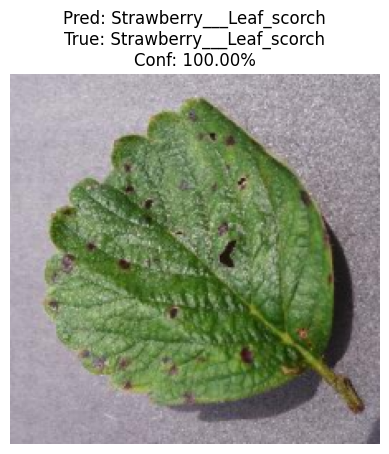

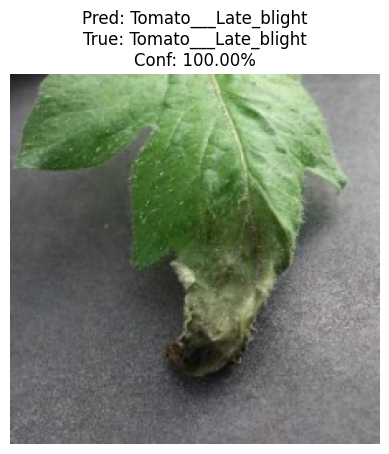

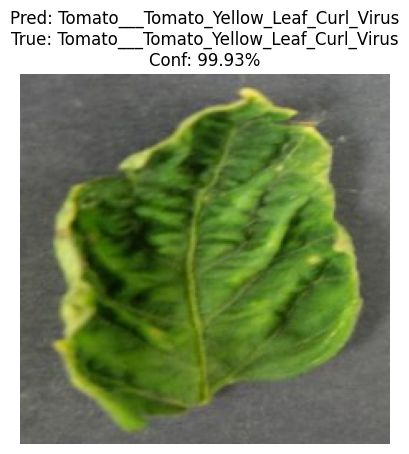

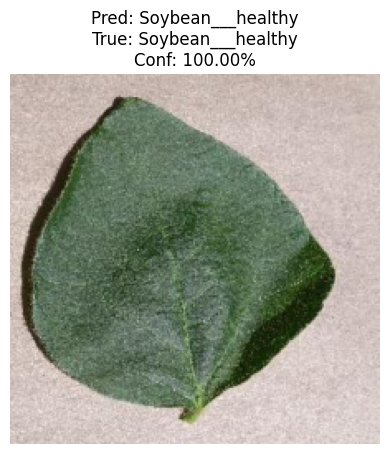

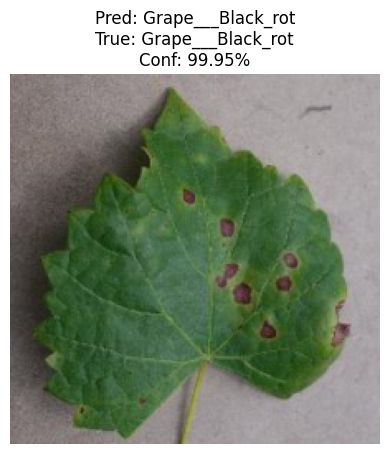

In [23]:
import random
import matplotlib.pyplot as plt
import torch.nn.functional as F

model.eval()

for i in range(5):
    img, label = val_dataset[random.randint(0, len(val_dataset)-1)]
    img_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = F.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, 1)
    
    plt.imshow(img.permute(1,2,0))
    plt.axis("off")
    plt.title(f"Pred: {class_names[pred.item()]}\nTrue: {class_names[label]}\nConf: {conf.item()*100:.2f}%")
    plt.show()

In [24]:
import json

class_names = full_dataset.classes

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("class_names.json saved successfully!")

class_names.json saved successfully!


In [25]:
!ls /kaggle/working

class_names.json  efficientnet_plant_best.pth
